In [48]:
import os
import random
import pandas as pd
import numpy as np
from pathlib import Path

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [49]:
print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.21.0
GPU: []


In [50]:
BASE_DIR = Path("../dataset/processed")

GARBAGE_DIR = BASE_DIR / "garbage" / "garbage_classification"

POTHOLE_DIR = BASE_DIR / "pothole" / "Dataset"

ROAD_DIR = BASE_DIR / "road_crack"

print("Paths Loaded Successfully")

Paths Loaded Successfully


In [51]:
IMAGE_EXTENSIONS = (".jpg", ".jpeg", ".png")


def get_images(folder):
    images = []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(IMAGE_EXTENSIONS):
                images.append(os.path.join(root, file))

    return images

In [52]:
data = []

In [53]:
data = []

# ----------------------------
# 1. Garbage
# ----------------------------
garbage_classes = os.listdir(GARBAGE_DIR)

for cls in garbage_classes:
    class_folder = GARBAGE_DIR / cls

    images = get_images(class_folder)

    for img in images:
        data.append({
            "image_path": img,
            "label": "garbage"
        })

print("Garbage Images:", len([d for d in data if d["label"] == "garbage"]))

Garbage Images: 15515


In [54]:
# ----------------------------
# 2. Pothole
# ----------------------------

# Train
images = get_images(POTHOLE_DIR / "train" / "Pothole")
for img in images:
    data.append({
        "image_path": img,
        "label": "pothole"
    })

# Validation
images = get_images(POTHOLE_DIR / "val" / "Pothole")
for img in images:
    data.append({
        "image_path": img,
        "label": "pothole"
    })

# Test (mixed folder)
test_folder = POTHOLE_DIR / "test"

for file in os.listdir(test_folder):
    if file.lower().startswith("pothole"):
        data.append({
            "image_path": str(test_folder / file),
            "label": "pothole"
        })

print("Pothole Images:", len([d for d in data if d["label"] == "pothole"]))

Pothole Images: 991


In [55]:
# ----------------------------
# 3. Road Crack
# ----------------------------

images = get_images(ROAD_DIR / "Positive")

for img in images:
    data.append({
        "image_path": img,
        "label": "road_crack"
    })

print("Road Crack Images:", len([d for d in data if d["label"] == "road_crack"]))

Road Crack Images: 20000


In [56]:
# ----------------------------
# 4. Normal
# ----------------------------

# Train
images = get_images(POTHOLE_DIR / "train" / "Normal")
for img in images:
    data.append({
        "image_path": img,
        "label": "normal"
    })

# Validation
images = get_images(POTHOLE_DIR / "val" / "Normal")
for img in images:
    data.append({
        "image_path": img,
        "label": "normal"
    })

# Test (mixed folder)
test_folder = POTHOLE_DIR / "test"

for file in os.listdir(test_folder):
    if file.lower().startswith("normal"):
        data.append({
            "image_path": str(test_folder / file),
            "label": "normal"
        })

# Road Crack Negative
images = get_images(ROAD_DIR / "Negative")

for img in images:
    data.append({
        "image_path": img,
        "label": "normal"
    })

print("Normal Images:", len([d for d in data if d["label"] == "normal"]))

Normal Images: 20410


In [57]:
df = pd.DataFrame(data)

print(df.head())

print("\nDataset Shape:", df.shape)

print("\nClass Distribution:")
print(df["label"].value_counts())

                                          image_path    label
0  ..\dataset\processed\garbage\garbage_classific...  garbage
1  ..\dataset\processed\garbage\garbage_classific...  garbage
2  ..\dataset\processed\garbage\garbage_classific...  garbage
3  ..\dataset\processed\garbage\garbage_classific...  garbage
4  ..\dataset\processed\garbage\garbage_classific...  garbage

Dataset Shape: (56916, 2)

Class Distribution:
label
normal        20410
road_crack    20000
garbage       15515
pothole         991
Name: count, dtype: int64


In [58]:
df.shape

(56916, 2)

In [59]:
df["label"].value_counts()

label
normal        20410
road_crack    20000
garbage       15515
pothole         991
Name: count, dtype: int64

In [60]:
# ----------------------------
# Create Smaller Dataset
# ----------------------------

garbage_df = df[df["label"] == "garbage"].sample(
    n=1000,
    random_state=42
)

normal_df = df[df["label"] == "normal"].sample(
    n=1000,
    random_state=42
)

road_df = df[df["label"] == "road_crack"].sample(
    n=1000,
    random_state=42
)

pothole_df = df[df["label"] == "pothole"]

small_df = pd.concat(
    [garbage_df, normal_df, road_df, pothole_df],
    ignore_index=True
)

small_df = shuffle(
    small_df,
    random_state=42
).reset_index(drop=True)

print(small_df["label"].value_counts())
print("\nTotal Images:", len(small_df))

label
normal        1000
road_crack    1000
garbage       1000
pothole        991
Name: count, dtype: int64

Total Images: 3991


In [61]:
# ----------------------------
# Split Small Dataset
# ----------------------------

train_df, temp_df = train_test_split(
    small_df,
    test_size=0.30,
    stratify=small_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (2793, 2)
Validation: (599, 2)
Test: (599, 2)


In [62]:
print("Training Distribution")
print(train_df["label"].value_counts())

print("\nValidation Distribution")
print(val_df["label"].value_counts())

print("\nTest Distribution")
print(test_df["label"].value_counts())

Training Distribution
label
road_crack    700
normal        700
garbage       700
pothole       693
Name: count, dtype: int64

Validation Distribution
label
normal        150
garbage       150
road_crack    150
pothole       149
Name: count, dtype: int64

Test Distribution
label
normal        150
road_crack    150
garbage       150
pothole       149
Name: count, dtype: int64


In [63]:
train_df.shape

(2793, 2)

In [64]:
val_df.shape

(599, 2)

In [65]:
test_df.shape

(599, 2)

In [66]:
train_datagen = ImageDataGenerator(
    rescale=1./255,

    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode="nearest"
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [67]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    shuffle=True
)

Found 2793 validated image filenames belonging to 4 classes.


In [68]:
val_generator = test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    shuffle=False
)

Found 599 validated image filenames belonging to 4 classes.


In [69]:
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    shuffle=False
)

Found 599 validated image filenames belonging to 4 classes.


In [70]:
print("Training Classes:")
print(train_generator.class_indices)

print("\nTraining Images:", train_generator.samples)

print("Validation Images:", val_generator.samples)

print("Testing Images:", test_generator.samples)

Training Classes:
{'garbage': 0, 'normal': 1, 'pothole': 2, 'road_crack': 3}

Training Images: 2793
Validation Images: 599
Testing Images: 599


In [71]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

# Convert to dictionary
class_weight_dict = {
    i: weight for i, weight in enumerate(class_weights)
}

print(class_weight_dict)

{0: np.float64(0.9975), 1: np.float64(0.9975), 2: np.float64(1.0075757575757576), 3: np.float64(0.9975)}


In [72]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained layers
base_model.trainable = False

# Add custom classifier
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(4, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [73]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [74]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np
import os

# Create models folder
os.makedirs("../models", exist_ok=True)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weight_dict = {
    i: weight for i, weight in enumerate(class_weights)
}

print("Class Weights:", class_weight_dict)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "../models/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=1,
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint]
)

Class Weights: {0: np.float64(0.9975), 1: np.float64(0.9975), 2: np.float64(1.0075757575757576), 3: np.float64(0.9975)}
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9352 - loss: 0.1997
Epoch 1: val_accuracy improved from None to 0.97663, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
88/88 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.9352 - loss: 0.1997 - val_accuracy: 0.9766 - val_loss: 0.0735
Restoring model weights from the end of the best epoch: 1.


In [75]:
# Evaluate on Test Set

loss, accuracy = model.evaluate(test_generator)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.9933 - loss: 0.0415
Test Loss: 0.0415
Test Accuracy: 0.9933


19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step
              precision    recall  f1-score   support

     garbage       1.00      0.99      1.00       150
      normal       0.99      0.98      0.99       150
     pothole       0.99      1.00      0.99       149
  road_crack       0.99      1.00      1.00       150

    accuracy                           0.99       599
   macro avg       0.99      0.99      0.99       599
weighted avg       0.99      0.99      0.99       599



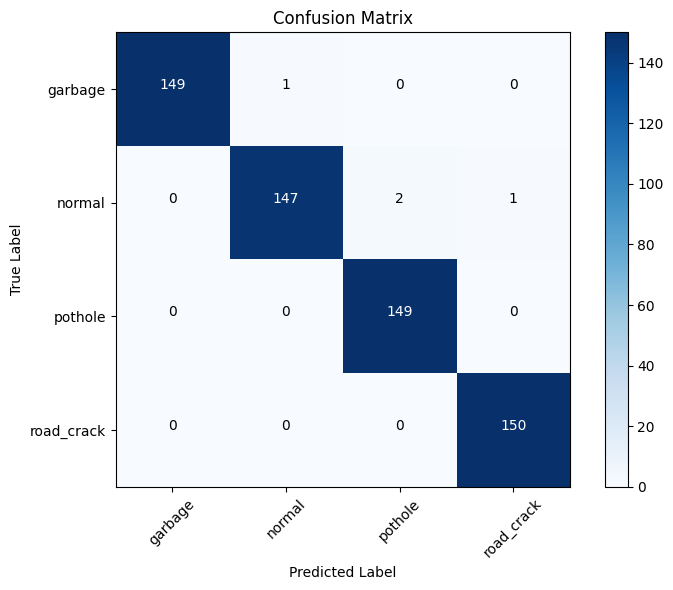

In [76]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import itertools

# Predict on test set
predictions = model.predict(test_generator)

# Predicted class
y_pred = np.argmax(predictions, axis=1)

# True class
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Classification Report
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j,
        i,
        cm[i, j],
        horizontalalignment="center",
        color="white" if cm[i, j] > cm.max()/2 else "black"
    )

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

# Save the Label Mapping

In [77]:
classes = list(train_generator.class_indices.keys())

with open("../models/class_names.txt", "w") as f:
    for c in classes:
        f.write(c + "\n")

print(classes)

['garbage', 'normal', 'pothole', 'road_crack']


In [82]:
from pathlib import Path
from PIL import Image
import numpy as np
import tensorflow as tf

model_path = Path("../models/best_model.keras")
labels_path = Path("../models/class_names.txt")
image_path = Path(r"../dataset\processed\archive (1)\Dataset\test\pothole835.jpg")

if image_path.name == "../dataset\processed\archive (1)\Dataset\test\pothole835.jpgE":
    raise ValueError(
        "Please set image_path to a valid image file path before running this cell."
    )

if not image_path.exists():
    raise FileNotFoundError(f"Image file not found: {image_path}")

if not model_path.exists():
    raise FileNotFoundError(
        f"Saved model not found: {model_path}. Run training first or check the path."
    )

model = tf.keras.models.load_model(str(model_path))

if labels_path.exists():
    with open(labels_path, "r") as f:
        class_names = [line.strip() for line in f if line.strip()]
else:
    class_names = ["garbage", "normal", "pothole", "road_crack"]
    print("Warning: class names file not found. Using default class order.")

image = Image.open(image_path).convert("RGB")
image_resized = image.resize((224, 224))
img_array = np.array(image_resized) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array, verbose=0)[0]
for name, probability in zip(class_names, prediction):
    print(f"{name}: {probability * 100:.2f}%")

predicted_index = int(np.argmax(prediction))
print("\nPredicted:", class_names[predicted_index])


<>:10: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\p'
C:\Users\eurika\AppData\Local\Temp\ipykernel_11876\3787554594.py:10: SyntaxWarning: invalid escape sequence '\p'
  if image_path.name == "../dataset\processed\archive (1)\Dataset\test\pothole835.jpgE":


garbage: 4.73%
normal: 64.15%
pothole: 0.06%
road_crack: 31.06%

Predicted: normal


In [85]:
print("Test DataFrame columns:")
print(test_df.columns.tolist())

print("\nFirst 5 rows:")
display(test_df.head())

Test DataFrame columns:
['image_path', 'label']

First 5 rows:


,image_path,label
3755,..\dataset\processed\road_crack\Negative\17280...,normal
521,..\dataset\processed\road_crack\Positive\11882...,road_crack
2921,..\dataset\processed\road_crack\Positive\03827...,road_crack
1211,..\dataset\processed\pothole\Dataset\train\Pot...,pothole
2524,..\dataset\processed\pothole\Dataset\train\Pot...,pothole


In [86]:
# Check whether pothole835.jpg is in our final test set

result = test_df[
    test_df["image_path"].str.contains(
        "pothole835",
        case=False,
        na=False
    )
]

display(result)

,image_path,label


In [87]:
import os

print(os.path.abspath("../models/best_model.keras"))
print(os.path.exists("../models/best_model.keras"))

d:\Zahid\AI-ML-Intern\Mid-Exam-Project\AI_Public_Infrastructure_Detection\models\best_model.keras
True


In [88]:
saved_model = tf.keras.models.load_model("../models/best_model.keras")
print("Saved model loaded successfully")

Saved model loaded successfully


In [89]:
image_path = r"../dataset/processed/archive (1)/Dataset/test/pothole835.jpg"

image = Image.open(image_path).convert("RGB")
image = image.resize((224, 224))

img_array = np.array(image) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = saved_model.predict(img_array, verbose=0)[0]

class_names = ["garbage", "normal", "pothole", "road_crack"]

for name, probability in zip(class_names, prediction):
    print(f"{name}: {probability * 100:.2f}%")

print("\nPredicted:", class_names[np.argmax(prediction)])

garbage: 4.73%
normal: 64.15%
pothole: 0.06%
road_crack: 31.06%

Predicted: normal


In [91]:
# Check pothole840 in our final dataset

result = test_df[
    test_df["image_path"].str.contains(
        "pothole840",
        case=False,
        na=False
    )
]

display(result)

,image_path,label
1074,..\dataset\processed\pothole\Dataset\train\Pot...,pothole
